In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.mask import mask
from shapely.geometry import box
from skimage import measure
from skimage.measure import regionprops, find_contours
from matplotlib.patches import Circle

In [2]:
# Bypass AWS credentials for access to public S3 data
os.environ['AWS_NO_SIGN_REQUEST'] = 'YES'

In [3]:
# NDVI calculation function
def calculate_ndvi(nir, red):
    """Calculate the NDVI using NIR and Red bands."""
    np.seterr(divide='ignore', invalid='ignore')
    ndvi = (nir - red) / (nir + red)
    return ndvi

In [4]:
def clip_band_to_bbox(band_path, bbox, downsample_factor=1):
    """Load a specific Sentinel-2 band from S3, clip it to the bounding box, and downsample."""
    try:
        with rasterio.open(band_path) as src:
            bbox_transformed = rasterio.warp.transform_bounds('EPSG:4326', src.crs, *bbox)
            bbox_geom = [box(*bbox_transformed)]
            out_image, out_transform = mask(src, bbox_geom, crop=True)
            out_image = out_image[0]  # Extract the first band
            if downsample_factor > 1:
                out_image = out_image[::downsample_factor, ::downsample_factor]
            return out_image, out_transform, src.crs
    except rasterio.errors.RasterioIOError as e:
        print(f"Error loading or clipping file: {band_path} - {e}")
        return None, None, None

In [5]:
def visualize_single_field(ndvi, field, labeled_fields, pixel_size=10):
    """Visualize a single isolated crop field with a smooth boundary and annotate acreage."""
    fig, ax = plt.subplots(figsize=(8, 8))
    
    field_mask = labeled_fields == field.label
    isolated_ndvi = np.ma.masked_where(~field_mask, ndvi)
    
    minr, minc, maxr, maxc = field.bbox
    ax.imshow(isolated_ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
    
    contours = find_contours(field_mask, level=0.5)
    for contour in contours:
        ax.plot(contour[:, 1], contour[:, 0], linewidth=2, color='yellow')
    
    field_area_m2 = field.area * (pixel_size ** 2)
    field_area_acres = field_area_m2 / 4046.86
    
    centroid = field.centroid
    ax.text(centroid[1], centroid[0], f"{field_area_acres:.2f} ac", color='black',
            fontsize=10, ha='center', va='center', bbox=dict(facecolor='white', alpha=0.7))
    
    ax.set_title(f"Crop Field - Acreage: {field_area_acres:.2f} ac", fontsize=14)
    ax.set_xlim(minc, maxc)
    ax.set_ylim(maxr, minr)
    
    cbar = fig.colorbar(ax.imshow(isolated_ndvi, cmap='RdYlGn', vmin=-1, vmax=1), ax=ax, fraction=0.03, pad=0.04)
    cbar.set_label('NDVI', fontsize=12)
    
    plt.show()

In [6]:
def optimized_debug_process_and_visualize_fields(red_band_path, nir_band_path, bbox, ndvi_threshold=0.5, min_area_pixels=100, min_dimension_pixels=5, downsample_factor=2, num_fields_to_visualize=3):
    """Optimized processing and visualization of Sentinel-2 fields with accuracy metrics and improved field markers."""
    red_band, _, _ = clip_band_to_bbox(red_band_path, bbox, downsample_factor)
    nir_band, _, _ = clip_band_to_bbox(nir_band_path, bbox, downsample_factor)
    
    if red_band is None or nir_band is None:
        print("Skipping processing due to missing data.")
        return
    
    # Step 1: Calculate NDVI with downsampling
    ndvi = calculate_ndvi(nir_band, red_band)
    print("NDVI calculated for the bounding box.")

    # Apply NDVI threshold and create crop mask
    crop_mask = ndvi > ndvi_threshold
    print(f"NDVI threshold applied: {ndvi_threshold}")
    print(f"Total crop pixels identified: {np.sum(crop_mask)}")
    
    # Label connected components in the crop mask
    labeled_fields, num_fields = measure.label(crop_mask, connectivity=2, return_num=True)
    field_properties = [
        prop for prop in regionprops(labeled_fields)
        if prop.area >= min_area_pixels and min(prop.bbox[2] - prop.bbox[0], prop.bbox[3] - prop.bbox[1]) >= min_dimension_pixels
    ]
    print(f"Number of fields detected after filtering: {len(field_properties)}")
    
    # Display a simplified full NDVI map with contours of detected fields
    plt.figure(figsize=(8, 6))
    plt.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
    
    if np.min(ndvi) != np.max(ndvi):  # Add colorbar only if NDVI has a range
        plt.colorbar(label="NDVI")
    
    for field in field_properties:
        field_mask = (labeled_fields == field.label)
        plt.contour(field_mask, colors='red', linewidths=0.8)
        centroid = field.centroid
        if 0 <= int(centroid[0]) < ndvi.shape[0] and 0 <= int(centroid[1]) < ndvi.shape[1]:
            plt.gca().add_patch(Circle((centroid[1], centroid[0]), 20, color='black', fill=False, linewidth=1.5))
    plt.title("Full NDVI Map with Field Contours (Red with Black Outline)")
    plt.show()

    # Visualize only the first few fields
    for i, field in enumerate(field_properties[:num_fields_to_visualize]):
        field_mask = (labeled_fields == field.label)
        field_ndvi_values = ndvi[field_mask]
        
        # Calculate field metrics
        field_area_m2 = field.area * (10 ** 2)  # Assuming 10m resolution
        field_area_acres = field_area_m2 / 4046.86
        shape_complexity = (field.perimeter ** 2) / field.area
        
        # Boundary Smoothness Check
        contours = find_contours(field_mask, level=0.5)
        avg_contour_length = np.mean([len(contour) for contour in contours]) if contours else 0
        
        print(f"Field {i+1} - Area (acres): {field_area_acres:.2f}, Shape Complexity: {shape_complexity:.2f}, Contour Length: {avg_contour_length:.2f}")

        # Visualize field with NDVI and accuracy annotations
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        
        # Display full NDVI with highlighted field
        ax[0].imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
        ax[0].contour(field_mask, colors='red', linewidths=1.5)
        if 0 <= int(field.centroid[0]) < ndvi.shape[0] and 0 <= int(field.centroid[1]) < ndvi.shape[1]:
            ax[0].add_patch(Circle((field.centroid[1], field.centroid[0]), 20, color='black', fill=False, linewidth=1.5))
        ax[0].set_title(f"Full NDVI with Field {i+1} Highlighted")
        
        # Zoomed-in field NDVI with acreage and metrics
        isolated_ndvi = np.where(field_mask, ndvi, np.nan)
        minr, minc, maxr, maxc = field.bbox
        if maxr <= ndvi.shape[0] and maxc <= ndvi.shape[1]:
            ax[1].imshow(isolated_ndvi[minr:maxr, minc:maxc], cmap='RdYlGn', vmin=-1, vmax=1)
            ax[1].text(0.5, 0.5, f"{field_area_acres:.2f} ac\nShape: {shape_complexity:.2f}\nContour: {avg_contour_length:.2f}", 
                       ha='center', va='center', transform=ax[1].transAxes, fontsize=10, color='black',
                       bbox=dict(facecolor='white', alpha=0.7))
            ax[1].set_title(f"Zoomed Field {i+1} - Acreage: {field_area_acres:.2f} ac")
        
        plt.show()

In [7]:
def internal_consistency_check(field_properties, pixel_size=10):
    """Perform internal consistency checks on field properties."""
    areas = [prop.area * (pixel_size ** 2) / 4046.86 for prop in field_properties]  # Convert to acres
    avg_area = np.mean(areas)
    shape_ratios = [prop.perimeter ** 2 / prop.area for prop in field_properties]
    avg_shape_ratio = np.mean(shape_ratios)
    
    print(f"Average Field Size (acres): {avg_area:.2f}")
    print(f"Average Shape Complexity (Perimeter^2 / Area): {avg_shape_ratio:.2f}")

In [8]:
def boundary_smoothness_check(field_properties, labeled_fields):
    """Check boundary smoothness by evaluating contour complexity for each field."""
    for i, field in enumerate(field_properties[:5]):
        field_mask = (labeled_fields == field.label)
        contours = find_contours(field_mask, level=0.5)
        
        contour_lengths = [len(contour) for contour in contours]
        avg_contour_length = np.mean(contour_lengths) if contour_lengths else 0
        
        print(f"Field {i+1} - Average Contour Length: {avg_contour_length:.2f}")
        if avg_contour_length > 100:
            print(f"Field {i+1} has a high contour complexity, indicating potential segmentation issues.")
        else:
            print(f"Field {i+1} has smooth boundaries.")

In [9]:
from sklearn.cluster import KMeans
def split_large_field(field_mask, ndvi, max_area_pixels=50000):
    """Split a large field using K-means clustering if it exceeds the maximum area."""
    if np.sum(field_mask) > max_area_pixels:
        print("Splitting large field using K-means clustering...")
        # Extract NDVI values within the field
        ndvi_values = ndvi[field_mask].reshape(-1, 1)
        # Apply K-means clustering to split into two clusters
        kmeans = KMeans(n_clusters=2, random_state=0).fit(ndvi_values)
        clustered_mask = np.zeros_like(field_mask, dtype=int)
        clustered_mask[field_mask] = kmeans.labels_ + 1  # +1 to ensure labels are 1 and 2
        return clustered_mask
    else:
        return field_mask  # Return original mask if not too large

NDVI calculated for the bounding box.
NDVI threshold applied: 0.5
Total crop pixels identified: 6358032
Number of fields detected after filtering: 348


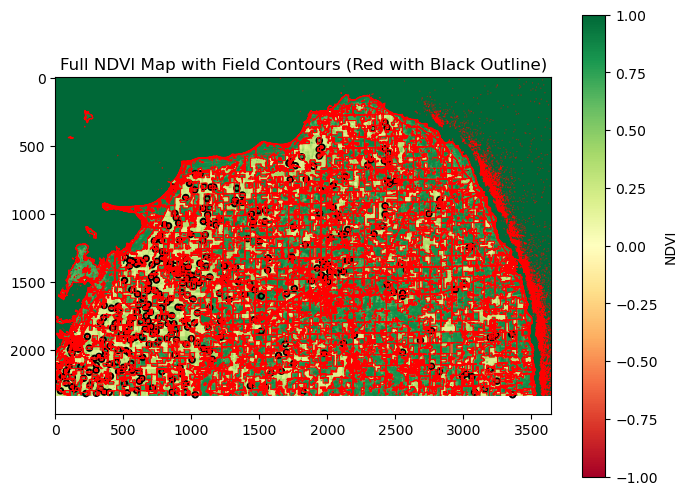

Field 1 - Area (acres): 143667.63, Shape Complexity: 41695.68, Contour Length: 21.18


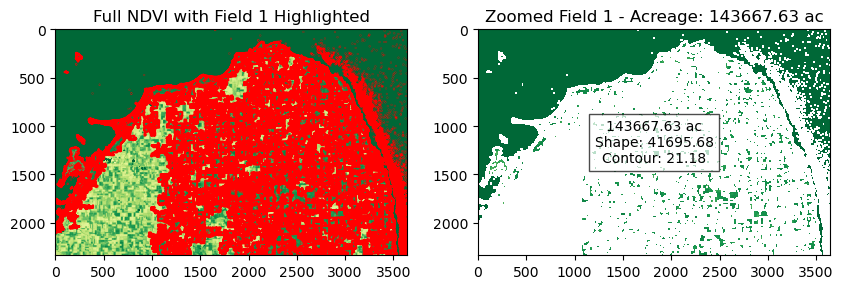

Field 2 - Area (acres): 14.28, Shape Complexity: 36.24, Contour Length: 54.33


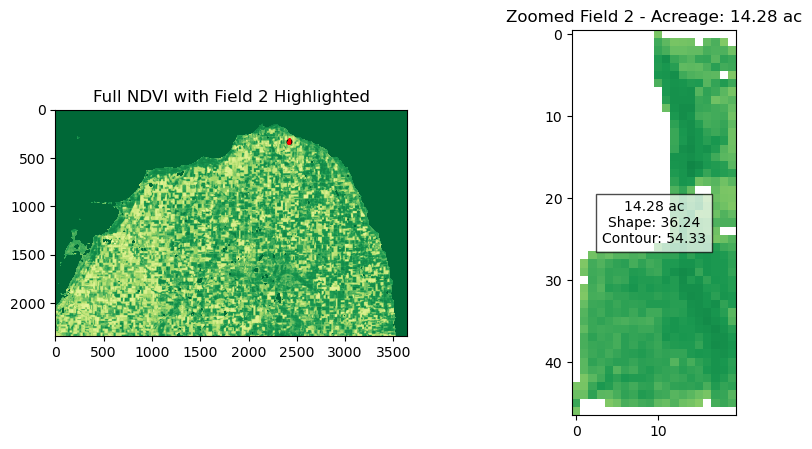

Field 3 - Area (acres): 12.21, Shape Complexity: 64.70, Contour Length: 40.67


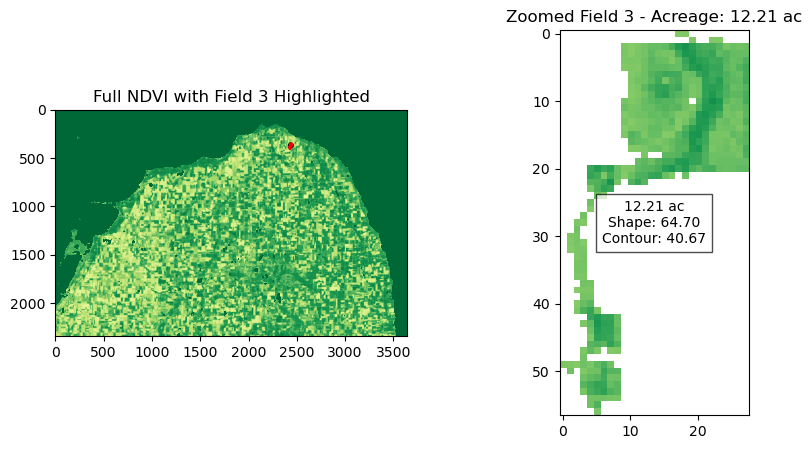

In [10]:
# Define the bounding box for Huron County, Michigan
huron_county_bbox = (-83.5941, 43.6764, -82.5872, 44.0789)

# Paths to NIR and Red bands
red_band_path = "/vsis3/sentinel-cogs/sentinel-s2-l2a-cogs/17/T/LJ/2024/9/S2A_17TLJ_20240915_0_L2A/B04.tif"
nir_band_path = "/vsis3/sentinel-cogs/sentinel-s2-l2a-cogs/17/T/LJ/2024/9/S2A_17TLJ_20240915_0_L2A/B08.tif"

optimized_debug_process_and_visualize_fields(
    red_band_path, nir_band_path, huron_county_bbox, ndvi_threshold=0.5, min_area_pixels=100, min_dimension_pixels=5, downsample_factor=2, num_fields_to_visualize=3
)

In [22]:
def plot_zoomed_ndvi(ndvi, labeled_fields, field_properties, bbox, title="Zoomed NDVI Map"):
    """
    Plots a zoomed-in NDVI map with field contours for a specified bounding box.
    """
    min_row, min_col, max_row, max_col = bbox
    min_row = max(0, min_row)
    min_col = max(0, min_col)
    max_row = min(ndvi.shape[0], max_row)
    max_col = min(ndvi.shape[1], max_col)
    
    zoomed_ndvi = ndvi[min_row:max_row, min_col:max_col]
    zoomed_labeled_fields = labeled_fields[min_row:max_row, min_col:max_col]

    plt.figure(figsize=(10, 8))
    im = plt.imshow(zoomed_ndvi, cmap="RdYlGn", vmin=-1, vmax=1)  # Capture the AxesImage object

    # Add field contours
    for field in field_properties:
        field_bbox = field.bbox
        if (
            field_bbox[0] >= min_row and field_bbox[2] <= max_row and
            field_bbox[1] >= min_col and field_bbox[3] <= max_col
        ):
            field_mask = (zoomed_labeled_fields == field.label)
            plt.contour(field_mask, colors="red", linewidths=0.8)

    plt.colorbar(im, label="NDVI")
    plt.title(title)
    plt.show()


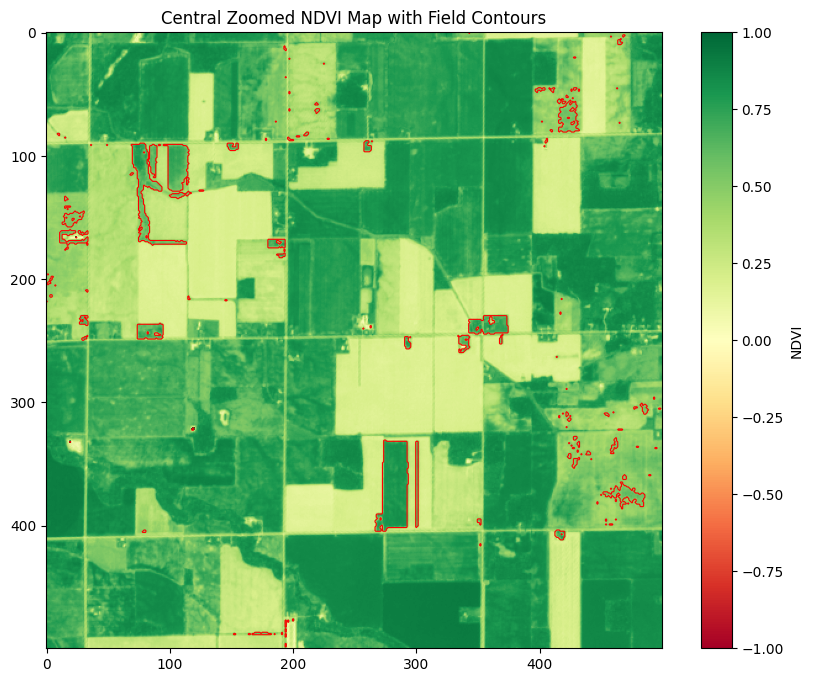

In [23]:
plot_zoomed_ndvi(
    ndvi=ndvi,
    labeled_fields=labeled_fields,
    field_properties=field_properties,
    bbox=zoom_bbox,
    title="Central Zoomed NDVI Map with Field Contours"
)


In [6]:
import numpy as np
import rasterio

red_band_path = "/vsis3/sentinel-cogs/sentinel-s2-l2a-cogs/17/T/LJ/2024/9/S2A_17TLJ_20240915_0_L2A/B04.tif"
nir_band_path = "/vsis3/sentinel-cogs/sentinel-s2-l2a-cogs/17/T/LJ/2024/9/S2A_17TLJ_20240915_0_L2A/B08.tif"

with rasterio.open(red_band_path) as red_src, rasterio.open(nir_band_path) as nir_src:
    red_band = red_src.read(1).astype(float) 
    nir_band = nir_src.read(1).astype(float)

#NDVI
ndvi = np.where((nir_band + red_band) == 0, 0, (nir_band - red_band) / (nir_band + red_band))

print(f"NDVI Min: {np.min(ndvi)}, NDVI Max: {np.max(ndvi)}, NDVI Mean: {np.mean(ndvi)}")


NDVI Min: -0.9834710743801653, NDVI Max: 0.9995079950799508, NDVI Mean: 0.1950558012264251


In [10]:
from pyproj import Transformer

transformer = Transformer.from_crs("EPSG:4326", "EPSG:32617", always_xy=True) 
xmin, ymin, xmax, ymax = huron_county_bbox
xmin_proj, ymin_proj = transformer.transform(xmin, ymin)
xmax_proj, ymax_proj = transformer.transform(xmax, ymax)
huron_county_bbox_proj = (xmin_proj, ymin_proj, xmax_proj, ymax_proj)


In [11]:
with rasterio.open(nir_band_path) as src:
    print("Raster CRS:", src.crs)


Raster CRS: EPSG:32617


In [12]:
from rasterio.windows import from_bounds

with rasterio.open(nir_band_path) as nir_src, rasterio.open(red_band_path) as red_src:
    bbox_window = from_bounds(*huron_county_bbox_proj, nir_src.transform)
    nir_band = nir_src.read(1, window=bbox_window).astype(float)
    red_band = red_src.read(1, window=bbox_window).astype(float)

# Calculate NDVI
ndvi = np.where((nir_band + red_band) == 0, 0, (nir_band - red_band) / (nir_band + red_band))
print("NDVI shape:", ndvi.shape)


NDVI shape: (4266, 7292)


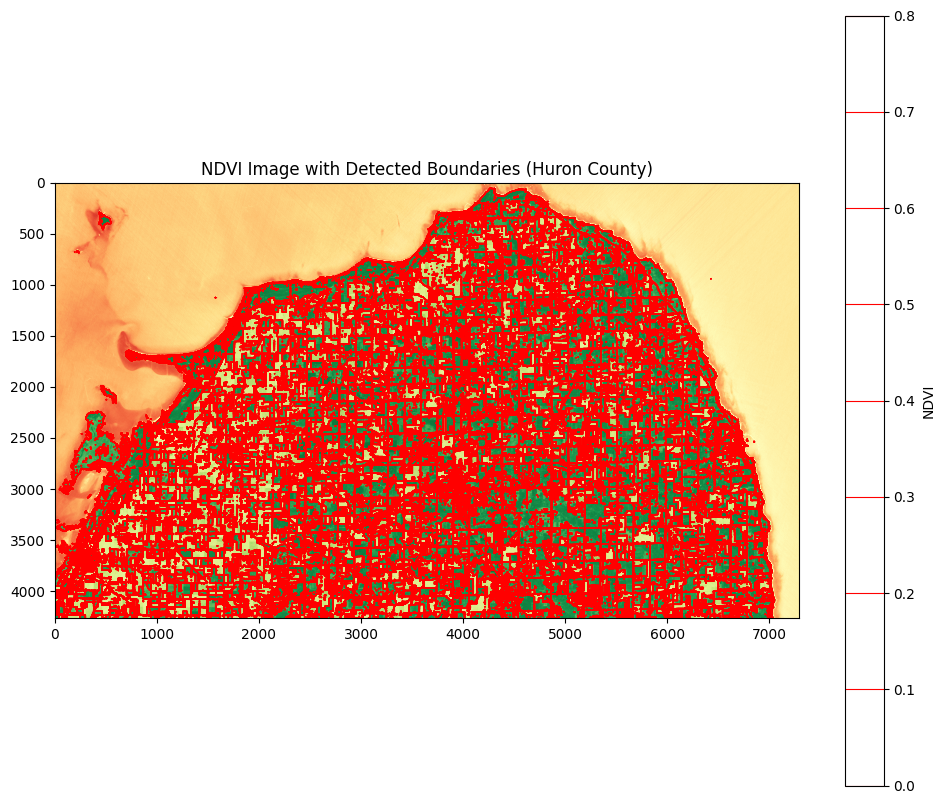

In [13]:
from skimage import filters

sobel_edges = filters.sobel(ndvi > 0.5)  # Use a binary mask for NDVI thresholding

plt.figure(figsize=(12, 10))
plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.contour(sobel_edges, colors="red", linewidths=0.8)
plt.colorbar(label="NDVI")
plt.title("NDVI Image with Detected Boundaries (Huron County)")
plt.show()


NDVI Min: -0.9834710743801653, NDVI Max: 0.9995079950799508, NDVI Shape: (10980, 10980)
Number of fields detected: 53600


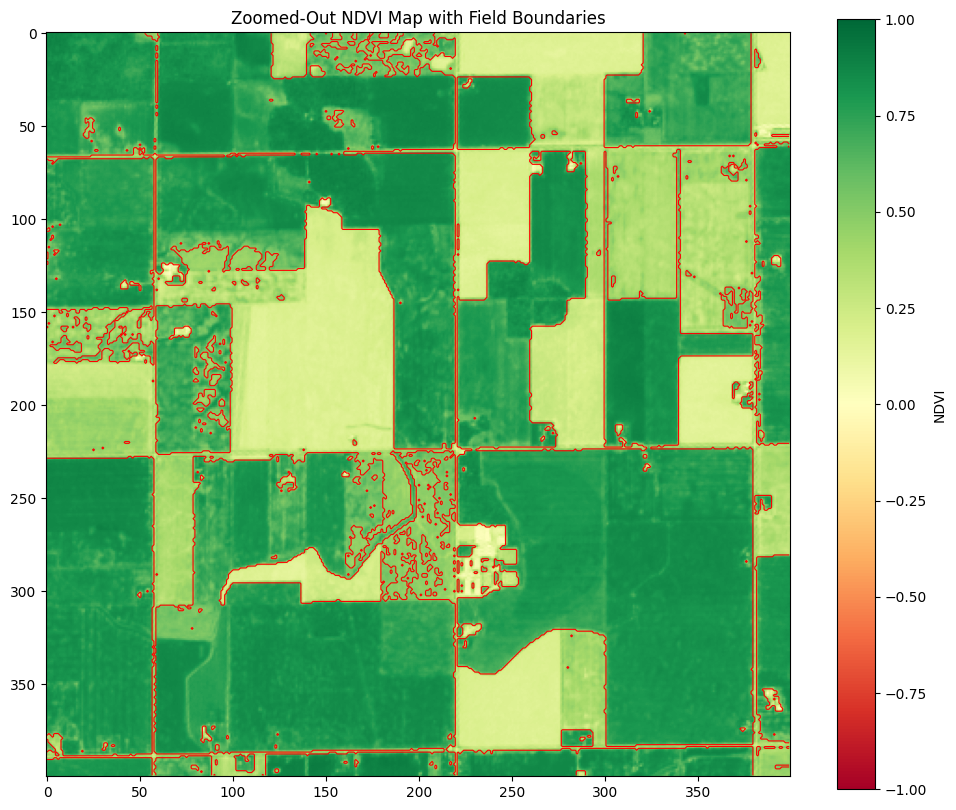

In [13]:
import rasterio
import numpy as np
from skimage.measure import label, regionprops
import matplotlib.pyplot as plt

red_band_path = "/vsis3/sentinel-cogs/sentinel-s2-l2a-cogs/17/T/LJ/2024/9/S2A_17TLJ_20240915_0_L2A/B04.tif"
nir_band_path = "/vsis3/sentinel-cogs/sentinel-s2-l2a-cogs/17/T/LJ/2024/9/S2A_17TLJ_20240915_0_L2A/B08.tif"

with rasterio.open(red_band_path) as red_src, rasterio.open(nir_band_path) as nir_src:
    red_band = red_src.read(1).astype(float)
    nir_band = nir_src.read(1).astype(float)

#Calculate NDVI
ndvi = np.where((nir_band + red_band) == 0, 0, (nir_band - red_band) / (nir_band + red_band))
print(f"NDVI Min: {np.min(ndvi)}, NDVI Max: {np.max(ndvi)}, NDVI Shape: {ndvi.shape}")

#Label Fields
ndvi_threshold = 0.5
binary_mask = ndvi > ndvi_threshold
labeled_fields, num_labels = label(binary_mask, connectivity=2, return_num=True)
print(f"Number of fields detected: {num_labels}")

zoom_size = 400  
center_row = ndvi.shape[0] // 2
center_col = ndvi.shape[1] // 2
zoom_bbox = (
    max(0, center_row - zoom_size // 2),
    max(0, center_col - zoom_size // 2),
    min(ndvi.shape[0], center_row + zoom_size // 2),
    min(ndvi.shape[1], center_col + zoom_size // 2),
)

def zoom_and_plot_ndvi_no_boxes(ndvi, labeled_fields, zoom_bbox, title="Zoomed-Out NDVI Map with Field Boundaries"):
    """
    Zoom into a specific region of the NDVI map and plot only red boundaries for the fields.

    Parameters:
    - ndvi: 2D NDVI array.
    - labeled_fields: Labeled field array from skimage.measure.label.
    - zoom_bbox: Tuple (min_row, min_col, max_row, max_col) defining the zoom area.
    - title: Title for the plot.
    """
    min_row, min_col, max_row, max_col = zoom_bbox

    if (min_row >= ndvi.shape[0] or max_row > ndvi.shape[0] or 
        min_col >= ndvi.shape[1] or max_col > ndvi.shape[1]):
        raise ValueError("Zoom bounding box exceeds NDVI array dimensions.")

    zoomed_ndvi = ndvi[min_row:max_row, min_col:max_col]
    zoomed_labeled_fields = labeled_fields[min_row:max_row, min_col:max_col]

    plt.figure(figsize=(12, 10))
    im = plt.imshow(zoomed_ndvi, cmap="RdYlGn", vmin=-1, vmax=1)

    for region in regionprops(zoomed_labeled_fields):
        field_mask = zoomed_labeled_fields == region.label
        plt.contour(field_mask, colors="red", linewidths=0.8)

    plt.colorbar(im, label="NDVI")
    plt.title(title)
    plt.show()

zoom_and_plot_ndvi_no_boxes(
    ndvi=ndvi,
    labeled_fields=labeled_fields,
    zoom_bbox=zoom_bbox,
    title="Zoomed-Out NDVI Map with Field Boundaries"
)


NDVI Min: -0.9834710743801653, NDVI Max: 0.9995079950799508, NDVI Shape: (10980, 10980)
Number of fields detected: 53600


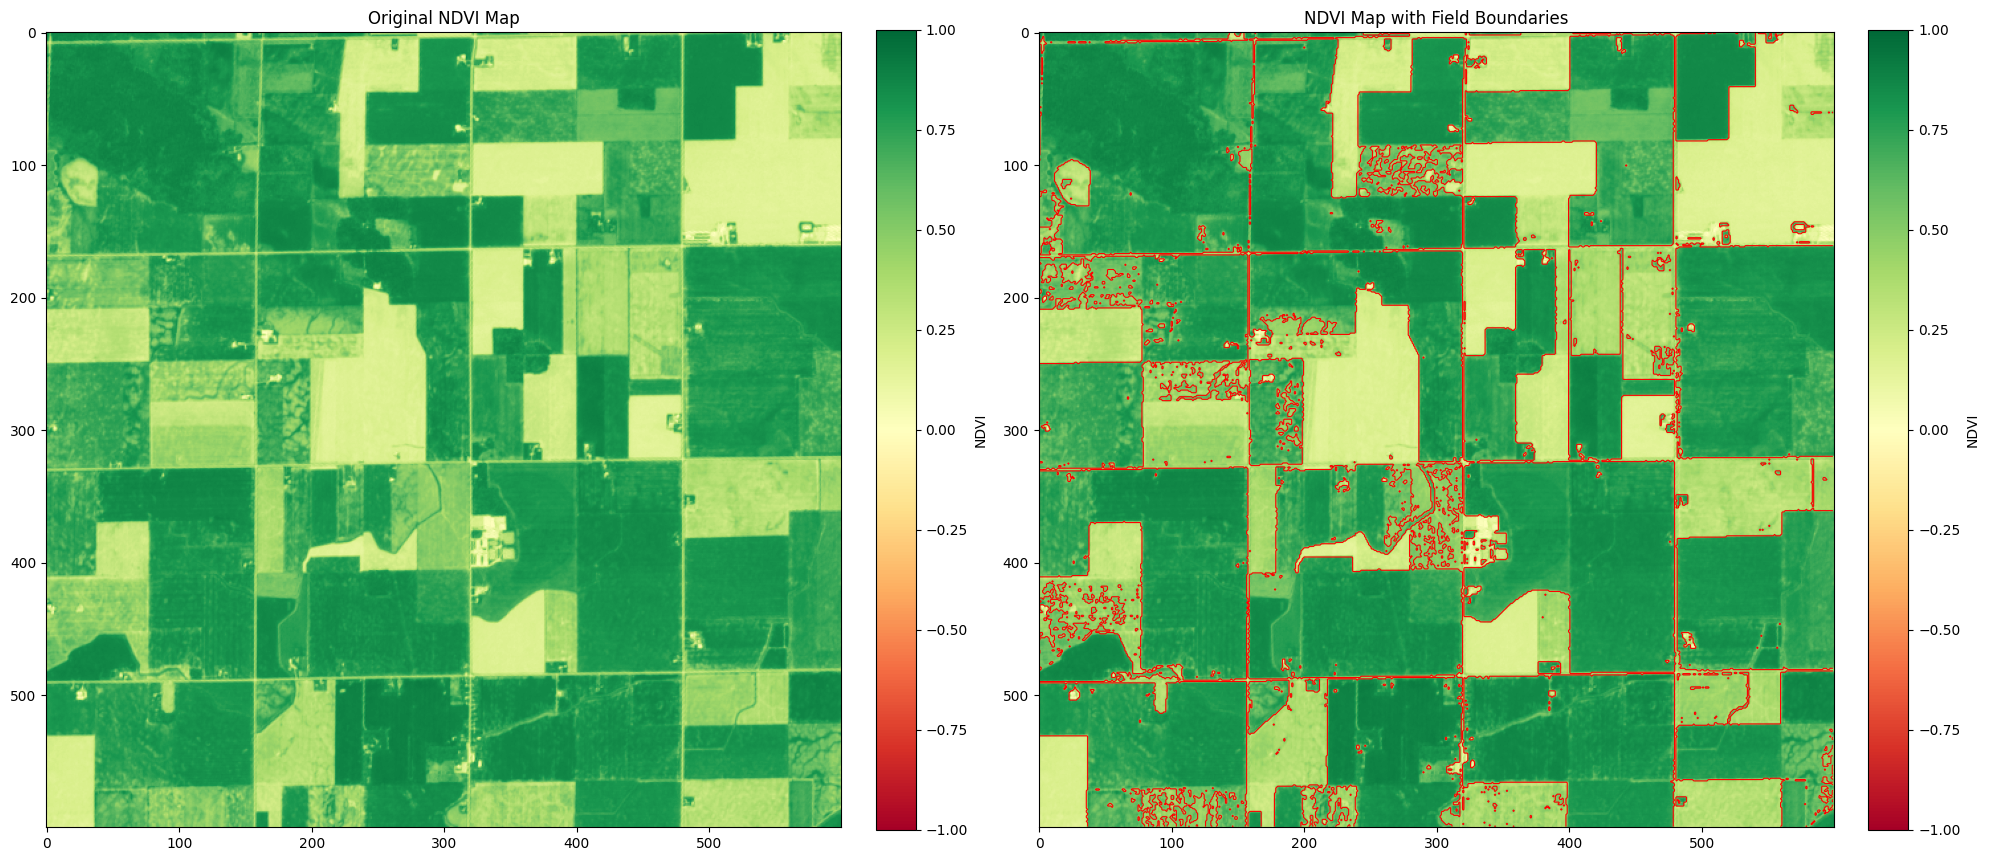

In [10]:
import rasterio
import numpy as np
from skimage.measure import label, regionprops
import matplotlib.pyplot as plt

red_band_path = "/vsis3/sentinel-cogs/sentinel-s2-l2a-cogs/17/T/LJ/2024/9/S2A_17TLJ_20240915_0_L2A/B04.tif"
nir_band_path = "/vsis3/sentinel-cogs/sentinel-s2-l2a-cogs/17/T/LJ/2024/9/S2A_17TLJ_20240915_0_L2A/B08.tif"

with rasterio.open(red_band_path) as red_src, rasterio.open(nir_band_path) as nir_src:
    red_band = red_src.read(1).astype(float)
    nir_band = nir_src.read(1).astype(float)

ndvi = np.where((nir_band + red_band) == 0, 0, (nir_band - red_band) / (nir_band + red_band))
print(f"NDVI Min: {np.min(ndvi)}, NDVI Max: {np.max(ndvi)}, NDVI Shape: {ndvi.shape}")

ndvi_threshold = 0.5
binary_mask = ndvi > ndvi_threshold
labeled_fields, num_labels = label(binary_mask, connectivity=2, return_num=True)
print(f"Number of fields detected: {num_labels}")

zoom_size = 600 
center_row = ndvi.shape[0] // 2
center_col = ndvi.shape[1] // 2
zoom_bbox = (
    max(0, center_row - zoom_size // 2),
    max(0, center_col - zoom_size // 2),
    min(ndvi.shape[0], center_row + zoom_size // 2),
    min(ndvi.shape[1], center_col + zoom_size // 2),
)

# Plot Both Maps Side by Side
def plot_side_by_side(ndvi, labeled_fields, zoom_bbox):
    """
    Plots the original NDVI map and the NDVI map with field boundaries side by side.

    Parameters:
    - ndvi: 2D NDVI array.
    - labeled_fields: Labeled field array from skimage.measure.label.
    - zoom_bbox: Tuple (min_row, min_col, max_row, max_col) defining the zoom area.
    """
    min_row, min_col, max_row, max_col = zoom_bbox

    zoomed_ndvi = ndvi[min_row:max_row, min_col:max_col]
    zoomed_labeled_fields = labeled_fields[min_row:max_row, min_col:max_col]

    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    im1 = axes[0].imshow(zoomed_ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
    axes[0].set_title("Original NDVI Map")
    plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04, label="NDVI")


    im2 = axes[1].imshow(zoomed_ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
    for region in regionprops(zoomed_labeled_fields):
        field_mask = zoomed_labeled_fields == region.label
        axes[1].contour(field_mask, colors="red", linewidths=0.8)
    axes[1].set_title("NDVI Map with Field Boundaries")
    plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04, label="NDVI")

    plt.tight_layout()
    plt.show()

plot_side_by_side(ndvi, labeled_fields, zoom_bbox)


In [ ]:
import rasterio
import numpy as np
from skimage.measure import label, regionprops
import matplotlib.pyplot as plt

red_band_path = "/vsis3/sentinel-cogs/sentinel-s2-l2a-cogs/17/T/LJ/2024/9/S2A_17TLJ_20240915_0_L2A/B04.tif"
nir_band_path = "/vsis3/sentinel-cogs/sentinel-s2-l2a-cogs/17/T/LJ/2024/9/S2A_17TLJ_20240915_0_L2A/B08.tif"

with rasterio.open(red_band_path) as red_src, rasterio.open(nir_band_path) as nir_src:
    red_band = red_src.read(1).astype(float)
    nir_band = nir_src.read(1).astype(float)

# Step 2: Calculate NDVI
ndvi = np.where((nir_band + red_band) == 0, 0, (nir_band - red_band) / (nir_band + red_band))
print(f"NDVI Min: {np.min(ndvi)}, NDVI Max: {np.max(ndvi)}, NDVI Shape: {ndvi.shape}")

# Step 3: Label Fields
ndvi_threshold = 0.5
binary_mask = ndvi > ndvi_threshold
labeled_fields, num_labels = label(binary_mask, connectivity=2, return_num=True)
print(f"Number of fields detected: {num_labels}")

# Step 4: Plot NDVI Map with Labeled Boundaries
def plot_ndvi_with_labels(ndvi, labeled_fields):
    """
    Plots the NDVI map with red field boundaries and labels each field with its number.

    Parameters:
    - ndvi: 2D NDVI array.
    - labeled_fields: Labeled field array from skimage.measure.label.
    """
    plt.figure(figsize=(12, 10))
    plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)

    # Loop through each detected field
    for region in regionprops(labeled_fields):
        field_mask = labeled_fields == region.label
        centroid = region.centroid  # Centroid of the field for placing the label
        plt.contour(field_mask, colors="red", linewidths=0.8)  # Red boundary

        # Add label at the centroid
        plt.text(
            centroid[1], centroid[0],  # X and Y coordinates
            f"Field {region.label}",  # Label text
            color="blue",
            fontsize=8,
            ha="center",
            va="center",
            bbox=dict(facecolor="white", alpha=0.5)  # Background box for visibility
        )

    plt.colorbar(label="NDVI")
    plt.title("NDVI Map with Field Boundaries and Labels")
    plt.show()

# Step 5: Call the Plot Function
plot_ndvi_with_labels(ndvi, labeled_fields)


NDVI Min: -0.9834710743801653, NDVI Max: 0.9995079950799508, NDVI Shape: (10980, 10980)
Number of fields detected: 53600


In [12]:
# Step 1: Define Spatial Resolution (in meters per pixel)
spatial_resolution = 10  # Sentinel-2 spatial resolution is 10m x 10m

# Step 2: Calculate Acreage for Each Field
acreage_list = []
for region in regionprops(labeled_fields):
    num_pixels = region.area  # Number of pixels in the field
    area_m2 = num_pixels * (spatial_resolution ** 2)  # Area in square meters
    area_acres = area_m2 / 4046.86  # Convert to acres
    acreage_list.append((region.label, area_acres))

# Step 3: Output Acreage for Each Field
print("Field Acreage (in acres):")
for field_id, acreage in acreage_list:
    print(f"Field {field_id}: {acreage:.2f} acres")

# Step 4: (Optional) Total Acreage
total_acreage = sum(acreage for _, acreage in acreage_list)
print(f"Total Acreage: {total_acreage:.2f} acres")


Field Acreage (in acres):
Field 1: 89849.78 acres
Field 2: 0.15 acres
Field 3: 0.07 acres
Field 4: 0.10 acres
Field 5: 0.22 acres
Field 6: 0.20 acres
Field 7: 0.12 acres
Field 8: 0.20 acres
Field 9: 0.02 acres
Field 10: 0.05 acres
Field 11: 0.02 acres
Field 12: 0.07 acres
Field 13: 0.02 acres
Field 14: 0.02 acres
Field 15: 0.05 acres
Field 16: 0.10 acres
Field 17: 0.17 acres
Field 18: 0.07 acres
Field 19: 0.02 acres
Field 20: 0.02 acres
Field 21: 0.07 acres
Field 22: 0.10 acres
Field 23: 0.22 acres
Field 24: 0.02 acres
Field 25: 0.05 acres
Field 26: 0.12 acres
Field 27: 0.49 acres
Field 28: 0.02 acres
Field 29: 0.05 acres
Field 30: 0.05 acres
Field 31: 0.02 acres
Field 32: 0.02 acres
Field 33: 0.10 acres
Field 34: 0.05 acres
Field 35: 0.02 acres
Field 36: 0.02 acres
Field 37: 0.07 acres
Field 38: 0.02 acres
Field 39: 0.02 acres
Field 40: 0.17 acres
Field 41: 0.05 acres
Field 42: 0.15 acres
Field 43: 0.02 acres
Field 44: 0.47 acres
Field 45: 0.47 acres
Field 46: 36302.27 acres
Field 47:

In [10]:
import rasterio
from rasterio.mask import mask
from shapely.geometry import box, Polygon 

red_band_path = "/vsis3/sentinel-cogs/sentinel-s2-l2a-cogs/17/T/LJ/2024/9/S2A_17TLJ_20240915_0_L2A/B04.tif"
nir_band_path = "/vsis3/sentinel-cogs/sentinel-s2-l2a-cogs/17/T/LJ/2024/9/S2A_17TLJ_20240915_0_L2A/B08.tif"

# Open the raster datasets
with rasterio.open(red_band_path) as red_ds, rasterio.open(nir_band_path) as nir_ds:
    # Print raster information for inspection
    print("Red band CRS:", red_ds.crs)
    print("Red band bounds:", red_ds.bounds)
    print("NIR band CRS:", nir_ds.crs)
    print("NIR band bounds:", nir_ds.bounds)

    # Define the bounding box geometry here
    huron_county_bbox = (-83.5941, 43.6764, -82.5872, 44.0789)
    bbox_geometry = box(*huron_county_bbox) 

    # Reproject bounding box to match the raster CRS
    bbox_gdf = gpd.GeoDataFrame(geometry=[bbox_geometry], crs='epsg:4326')
    bbox_gdf = bbox_gdf.to_crs(red_ds.crs)
    bbox_geometry = bbox_gdf.geometry[0]

    # Clip the bands
    red_band, red_transform = mask(red_ds, [bbox_geometry], crop=True)
    red_band = red_band.squeeze()
    nir_band, nir_transform = mask(nir_ds, [bbox_geometry], crop=True)
    nir_band = nir_band.squeeze()

# Print shapes of clipped bands
print("Clipped red band shape:", red_band.shape)
print("Clipped NIR band shape:", nir_band.shape)

Red band CRS: EPSG:32617
Red band bounds: BoundingBox(left=300000.0, bottom=4790220.0, right=409800.0, top=4900020.0)
NIR band CRS: EPSG:32617
NIR band bounds: BoundingBox(left=300000.0, bottom=4790220.0, right=409800.0, top=4900020.0)
Clipped red band shape: (4676, 7292)
Clipped NIR band shape: (4676, 7292)


In [15]:
import nbformat  # Ensure this is imported

def count_lines_of_code(notebook_path):
    with open(notebook_path, 'r') as nb_file:
        nb_data = nbformat.read(nb_file, as_version=4)
    total_lines = sum(
        len(cell['source'].splitlines()) for cell in nb_data['cells'] if cell['cell_type'] == 'code'
    )
    print(f"Total Lines of Code: {total_lines}")
    return total_lines

# Run the function with the correct file path
lines_of_code = count_lines_of_code('/Users/vswynnie/Desktop/Pixel clusterization and NDVI.ipynb')

lines_of_code


Total Lines of Code: 604


604

In [17]:
import psutil

# Start monitoring CPU usage
cpu_percentages = []

# Wrap your function in a loop to monitor CPU usage
for _ in range(5):  # Adjust iterations as needed for longer processes
    # Call your pixel clustering function here
    # Example: clustering_result = your_clustering_function()
    cpu_percentages.append(psutil.cpu_percent(interval=1))

mean_cpu_usage = sum(cpu_percentages) / len(cpu_percentages)
print(f"Mean CPU Usage: {mean_cpu_usage:.2f}%")


Mean CPU Usage: 7.26%
